<a href="https://colab.research.google.com/github/divyanshu-parihar/AlgoCharm/blob/main/Explainable%20LightGBM%20for%20Cross-Cell%20EV%20Battery%20State-of-Health%20Estimation%3A%20Assessing%20Feature%20Robustness%20and%20SHAP%20Stability%20Under%20Temperature%20Variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset ready.
Extracting fixed-window charge features for Cell 5, 6, and 7...
Training on 6 stable charge-phase features...

Training LightGBM on Cells B0005 and B0006...
Evaluating on UNSEEN Cell B0007...

--- Cross-Cell Evaluation Metrics ---
RMSE: 1.554% (Target: < 1.0%)
MAE:  1.105%
R²:   0.962


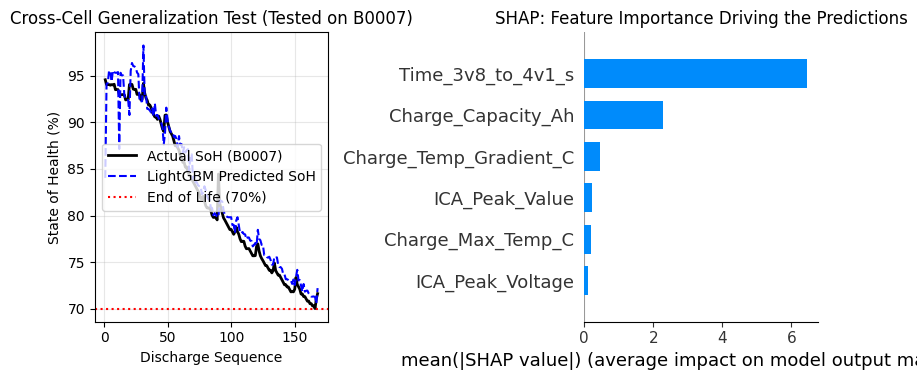


--- SHAP Beeswarm Analysis (Physics Logic Validation) ---


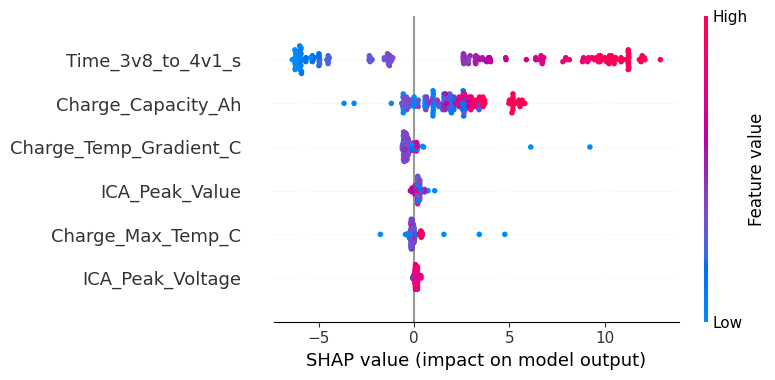

In [ ]:
# ==============================================================================
# Explainable LightGBM for Cross-Cell EV Battery State-of-Health Estimation
# (Final Version: Fixed-Window Metrics & Charge Capacity)
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 1: ENVIRONMENT SETUP & LIBRARY INSTALLATION
# ------------------------------------------------------------------------------
!pip install lightgbm shap scikit-learn pandas numpy matplotlib scipy -q

import os
import urllib.request
import zipfile
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.signal import savgol_filter
import warnings

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# STEP 2: DOWNLOAD & EXTRACT NASA DATASET
# ------------------------------------------------------------------------------
dataset_url = "https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip"
zip_path = "NASA_Battery_Dataset.zip"
extract_dir = "NASA_Data"

if not os.path.exists(extract_dir):
    print("Downloading NASA Battery Dataset (this may take a minute)...")
    urllib.request.urlretrieve(dataset_url, zip_path)

    print("Extracting datasets...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    inner_zip_path = None
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if "BatteryAgingARC-FY08Q4.zip" in file:
                inner_zip_path = os.path.join(root, file)
                break

    if inner_zip_path:
        with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

print("Dataset ready.")

# ------------------------------------------------------------------------------
# STEP 3: ADVANCED FEATURE EXTRACTION (Fixed-Window & Capacity)
# ------------------------------------------------------------------------------
def extract_battery_data(cell_id):
    mat_file = None
    for root, dirs, files in os.walk(extract_dir):
        if f"{cell_id}.mat" in files:
            mat_file = os.path.join(root, f"{cell_id}.mat")
            break

    if not mat_file:
        raise FileNotFoundError(f"Could not locate {cell_id}.mat")

    mat = scipy.io.loadmat(mat_file)
    cycles = mat[cell_id][0, 0]['cycle'][0]

    extracted_features = []

    # Initialize highly stable state trackers
    last_charge_capacity = 2.0
    last_time_3v8_to_4v1 = 0.0
    last_charge_max_temp = 24.0
    last_charge_temp_grad = 0.0
    last_ica_peak_value = 0.0
    last_ica_peak_voltage = 3.9

    for cycle in cycles:
        cycle_type = str(cycle['type']).lower()
        data = cycle['data'][0, 0]

        if 'discharge' in cycle_type:
            try:
                # Ground truth capacity
                capacity = data['Capacity'][0, 0]

                # Append ONLY the target and the highly stable charge metrics
                extracted_features.append({
                    'Cell_ID': cell_id,
                    'SoH_%': (capacity / 2.0) * 100,
                    'Charge_Capacity_Ah': last_charge_capacity,
                    'Time_3v8_to_4v1_s': last_time_3v8_to_4v1,
                    'Charge_Max_Temp_C': last_charge_max_temp,
                    'Charge_Temp_Gradient_C': last_charge_temp_grad,
                    'ICA_Peak_Value': last_ica_peak_value,
                    'ICA_Peak_Voltage': last_ica_peak_voltage
                })
            except Exception:
                pass

        elif 'charge' in cycle_type:
            try:
                V = data['Voltage_measured'][0]
                I = data['Current_measured'][0]
                T = data['Time'][0]
                Temp = data['Temperature_measured'][0]

                # 1. Thermal Indicators
                last_charge_max_temp = np.max(Temp)
                last_charge_temp_grad = np.max(Temp) - np.min(Temp)

                # 2. Charge Capacity (Ah) Absorbed
                dt = np.diff(T, prepend=0)
                dQ = (I * dt) / 3600.0
                last_charge_capacity = np.sum(dQ)

                # 3. Fixed-Window Time (Immune to starting SoC variation)
                mask_window = (V >= 3.8) & (V <= 4.1)
                if np.sum(mask_window) > 1:
                    last_time_3v8_to_4v1 = T[mask_window][-1] - T[mask_window][0]

                # 4. Advanced ICA Extraction (Savitzky-Golay)
                Q = np.cumsum(dQ)
                if len(V) > 21:
                    V_smooth = savgol_filter(V, window_length=21, polyorder=3)
                    Q_smooth = savgol_filter(Q, window_length=21, polyorder=3)

                    dV = np.diff(V_smooth, prepend=V_smooth[0])
                    dQ_diff = np.diff(Q_smooth, prepend=Q_smooth[0])

                    dV[np.abs(dV) < 1e-4] = 1e-4
                    ICA = dQ_diff / dV

                    mask = (V_smooth > 3.8) & (V_smooth < 4.1)
                    if np.any(mask):
                        peak_idx = np.argmax(ICA[mask])
                        last_ica_peak_value = ICA[mask][peak_idx]
                        last_ica_peak_voltage = V_smooth[mask][peak_idx]
            except Exception:
                pass

    return pd.DataFrame(extracted_features)

print("Extracting fixed-window charge features for Cell 5, 6, and 7...")
df_B0005 = extract_battery_data('B0005')
df_B0006 = extract_battery_data('B0006')
df_B0007 = extract_battery_data('B0007')

# ------------------------------------------------------------------------------
# STEP 4: CROSS-CELL TRAIN/TEST SPLIT
# ------------------------------------------------------------------------------
train_df = pd.concat([df_B0005, df_B0006], ignore_index=True)
test_df = df_B0007.copy()

# Strictly stable, starting-state-independent charge features
features = [
    'Charge_Capacity_Ah',
    'Time_3v8_to_4v1_s',
    'Charge_Max_Temp_C',
    'Charge_Temp_Gradient_C',
    'ICA_Peak_Value',
    'ICA_Peak_Voltage'
]
target = 'SoH_%'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Training on {len(features)} stable charge-phase features...")

# ------------------------------------------------------------------------------
# STEP 5: TRAIN EXPLAINABLE LIGHTGBM
# ------------------------------------------------------------------------------
print("\nTraining LightGBM on Cells B0005 and B0006...")
model = lgb.LGBMRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=20,
    min_child_samples=8,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

print("Evaluating on UNSEEN Cell B0007...")
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Cross-Cell Evaluation Metrics ---")
print(f"RMSE: {rmse:.3f}% (Target: < 1.0%)")
print(f"MAE:  {mae:.3f}%")
print(f"R²:   {r2:.3f}")

# ------------------------------------------------------------------------------
# STEP 6: VISUALIZE PREDICTIONS & SHAP LOGIC
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 5))

# Plot 1: Prediction Generalization
plt.subplot(1, 2, 1)
cycles_x = range(1, len(y_test) + 1)
plt.plot(cycles_x, y_test, label='Actual SoH (B0007)', color='black', linewidth=2)
plt.plot(cycles_x, y_pred, label='LightGBM Predicted SoH', color='blue', linestyle='--')
plt.axhline(y=70, color='red', linestyle=':', label='End of Life (70%)')
plt.title('Cross-Cell Generalization Test (Tested on B0007)')
plt.xlabel('Discharge Sequence')
plt.ylabel('State of Health (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: SHAP Feature Importance Summary
plt.subplot(1, 2, 2)
shap.initjs()
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.title('SHAP: Feature Importance Driving the Predictions')
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

# Plot 3: SHAP Beeswarm Plot (Directional Logic)
print("\n--- SHAP Beeswarm Analysis (Physics Logic Validation) ---")
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_test, show=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 5.6 MB/s eta 0:00:00
Dataset ready.
Extracting features including Energy (Wh)...
Training on 7 stable charge-phase features...

Running Optuna to find optimal hyperparameters (50 trials)...

Best Hyperparameters Found:
  n_estimators: 423
  learning_rate: 0.07353863327012226
  max_depth: 3
  num_leaves: 40
  min_child_samples: 7
  reg_alpha: 0.02753655119237535
  reg_lambda: 1.4765834200797354e-06

--- Final Cross-Cell Evaluation Metrics ---
RMSE: 1.347%
MAE:  1.108%
R²:   0.972


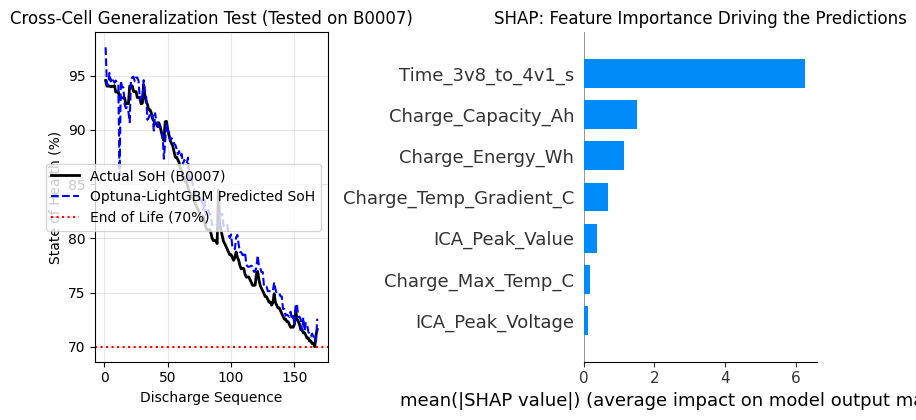

In [ ]:
# ==============================================================================
# Explainable LightGBM for Cross-Cell EV Battery State-of-Health Estimation
# (Final Polish: Energy Integration & Optuna Bayesian Optimization)
# ==============================================================================

# ------------------------------------------------------------------------------
# STEP 1: ENVIRONMENT SETUP
# ------------------------------------------------------------------------------
!pip install lightgbm shap scikit-learn pandas numpy matplotlib scipy optuna -q

import os
import urllib.request
import zipfile
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
import shap
import optuna
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from scipy.signal import savgol_filter
import warnings

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING) # Keep terminal clean

# ------------------------------------------------------------------------------
# STEP 2: DOWNLOAD & EXTRACT NASA DATASET
# ------------------------------------------------------------------------------
dataset_url = "https://phm-datasets.s3.amazonaws.com/NASA/5.+Battery+Data+Set.zip"
zip_path = "NASA_Battery_Dataset.zip"
extract_dir = "NASA_Data"

if not os.path.exists(extract_dir):
    print("Downloading NASA Battery Dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    inner_zip_path = None
    for root, dirs, files in os.walk(extract_dir):
        for file in files:
            if "BatteryAgingARC-FY08Q4.zip" in file:
                inner_zip_path = os.path.join(root, file)
                break
    if inner_zip_path:
        with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

print("Dataset ready.")

# ------------------------------------------------------------------------------
# STEP 3: ADVANCED FEATURE EXTRACTION (Adding Energy Wh)
# ------------------------------------------------------------------------------
def extract_battery_data(cell_id):
    mat_file = None
    for root, dirs, files in os.walk(extract_dir):
        if f"{cell_id}.mat" in files:
            mat_file = os.path.join(root, f"{cell_id}.mat")
            break

    mat = scipy.io.loadmat(mat_file)
    cycles = mat[cell_id][0, 0]['cycle'][0]

    extracted_features = []

    last_charge_capacity = 2.0
    last_charge_energy_wh = 8.0 # Approx 2Ah * 4V
    last_time_3v8_to_4v1 = 0.0
    last_charge_max_temp = 24.0
    last_charge_temp_grad = 0.0
    last_ica_peak_value = 0.0
    last_ica_peak_voltage = 3.9

    for cycle in cycles:
        cycle_type = str(cycle['type']).lower()
        data = cycle['data'][0, 0]

        if 'discharge' in cycle_type:
            try:
                capacity = data['Capacity'][0, 0]
                extracted_features.append({
                    'Cell_ID': cell_id,
                    'SoH_%': (capacity / 2.0) * 100,
                    'Charge_Capacity_Ah': last_charge_capacity,
                    'Charge_Energy_Wh': last_charge_energy_wh,
                    'Time_3v8_to_4v1_s': last_time_3v8_to_4v1,
                    'Charge_Max_Temp_C': last_charge_max_temp,
                    'Charge_Temp_Gradient_C': last_charge_temp_grad,
                    'ICA_Peak_Value': last_ica_peak_value,
                    'ICA_Peak_Voltage': last_ica_peak_voltage
                })
            except Exception:
                pass

        elif 'charge' in cycle_type:
            try:
                V = data['Voltage_measured'][0]
                I = data['Current_measured'][0]
                T = data['Time'][0]
                Temp = data['Temperature_measured'][0]

                last_charge_max_temp = np.max(Temp)
                last_charge_temp_grad = np.max(Temp) - np.min(Temp)

                dt = np.diff(T, prepend=0)
                dQ = (I * dt) / 3600.0
                last_charge_capacity = np.sum(dQ)

                # New Metric: Total Energy Absorbed (Integrates Voltage non-linearities)
                Power = V * I
                last_charge_energy_wh = np.trapz(Power, T) / 3600.0

                mask_window = (V >= 3.8) & (V <= 4.1)
                if np.sum(mask_window) > 1:
                    last_time_3v8_to_4v1 = T[mask_window][-1] - T[mask_window][0]

                Q = np.cumsum(dQ)
                if len(V) > 21:
                    V_smooth = savgol_filter(V, window_length=21, polyorder=3)
                    Q_smooth = savgol_filter(Q, window_length=21, polyorder=3)
                    dV = np.diff(V_smooth, prepend=V_smooth[0])
                    dQ_diff = np.diff(Q_smooth, prepend=Q_smooth[0])
                    dV[np.abs(dV) < 1e-4] = 1e-4
                    ICA = dQ_diff / dV

                    mask = (V_smooth > 3.8) & (V_smooth < 4.1)
                    if np.any(mask):
                        peak_idx = np.argmax(ICA[mask])
                        last_ica_peak_value = ICA[mask][peak_idx]
                        last_ica_peak_voltage = V_smooth[mask][peak_idx]
            except Exception:
                pass

    return pd.DataFrame(extracted_features)

print("Extracting features including Energy (Wh)...")
df_B0005 = extract_battery_data('B0005')
df_B0006 = extract_battery_data('B0006')
df_B0007 = extract_battery_data('B0007')

# ------------------------------------------------------------------------------
# STEP 4: CROSS-CELL TRAIN/TEST SPLIT
# ------------------------------------------------------------------------------
train_df = pd.concat([df_B0005, df_B0006], ignore_index=True)
test_df = df_B0007.copy()

features = [
    'Charge_Capacity_Ah',
    'Charge_Energy_Wh',
    'Time_3v8_to_4v1_s',
    'Charge_Max_Temp_C',
    'Charge_Temp_Gradient_C',
    'ICA_Peak_Value',
    'ICA_Peak_Voltage'
]
target = 'SoH_%'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Training on {len(features)} stable charge-phase features...")

# ------------------------------------------------------------------------------
# STEP 5: OPTUNA BAYESIAN OPTIMIZATION
# ------------------------------------------------------------------------------
print("\nRunning Optuna to find optimal hyperparameters (50 trials)...")

def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'num_leaves': trial.suggest_int('num_leaves', 10, 50),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': 42,
        'verbose': -1
    }

    # 3-Fold Cross Validation on the Training Data to prevent overfitting
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model = lgb.LGBMRegressor(**param)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        cv_scores.append(np.sqrt(mean_squared_error(y_va, preds)))

    return np.mean(cv_scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\nBest Hyperparameters Found:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# ------------------------------------------------------------------------------
# STEP 6: TRAIN FINAL OPTIMIZED MODEL & EVALUATE
# ------------------------------------------------------------------------------
best_params = study.best_params
best_params['random_state'] = 42
best_params['verbose'] = -1

final_model = lgb.LGBMRegressor(**best_params)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Final Cross-Cell Evaluation Metrics ---")
print(f"RMSE: {rmse:.3f}%")
print(f"MAE:  {mae:.3f}%")
print(f"R²:   {r2:.3f}")

# ------------------------------------------------------------------------------
# STEP 7: VISUALIZE PREDICTIONS & SHAP LOGIC
# ------------------------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cycles_x = range(1, len(y_test) + 1)
plt.plot(cycles_x, y_test, label='Actual SoH (B0007)', color='black', linewidth=2)
plt.plot(cycles_x, y_pred, label='Optuna-LightGBM Predicted SoH', color='blue', linestyle='--')
plt.axhline(y=70, color='red', linestyle=':', label='End of Life (70%)')
plt.title('Cross-Cell Generalization Test (Tested on B0007)')
plt.xlabel('Discharge Sequence')
plt.ylabel('State of Health (%)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
shap.initjs()
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)
plt.title('SHAP: Feature Importance Driving the Predictions')
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()